# Lexical features, borrower outcomes, and loan purpose

This notebook brings the lexical EDA into one place. It starts with a narrow question: do the six lexical features separate defaulted and non-defaulted borrowers on the frozen training split? It then looks at loan purpose and checks whether the distress-keyword feature is measuring borrower prose or simply repeating a category label.

The analysis uses 86,293 training rows. Validation and test outcomes are not used.

## Load the aggregate results

The heavy work lives in `src/nlp/lexical_eda.py`. That script checks the source hash, joins the frozen training IDs, recomputes keyword counts from each text field, and writes the aggregate tables used below. Keeping that logic outside the notebook makes the results easier to test and reproduce.

In [1]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / 'reports' / 'nlp' / 'lexical_eda_metrics.json').exists()
)
sys.path.insert(0, str(ROOT))
from src.nlp.lexical_eda import (
    build_correlation_figure,
    build_keyword_sources_figure,
    build_outcome_means_figure,
    build_purpose_profile_figure,
)
REPORT_DIR = ROOT / 'reports' / 'nlp'

correlations = pd.read_csv(REPORT_DIR / 'lexical_feature_correlations.csv')
outcome_summary = pd.read_csv(REPORT_DIR / 'lexical_feature_outcome_summary.csv')
purpose_summary = pd.read_csv(REPORT_DIR / 'lexical_purpose_summary.csv')
metrics = json.loads((REPORT_DIR / 'lexical_eda_metrics.json').read_text())

metrics['training_rows'], metrics['defaults'], metrics['empirical_default_rate']

(86293, 13197, 0.1529324510678734)

## 1. The lexical features have weak separation

Sentiment polarity ranks first by absolute point-biserial correlation, but the value is only **-0.0207**. Defaulted borrowers have slightly lower average polarity and subjectivity, slightly harder-to-read text, and slightly more distress keywords. The gaps are consistent enough to produce small p-values in a large sample, yet they remain too small to support a useful decision rule on their own.

Reading grade has `r = 0.0131`, while distress-keyword density has `r = 0.0112`. In practical terms, grade level separates the outcomes only a little more than the keyword feature.

,feature,point_biserial_r,p_value,non_default_mean,default_mean,default_minus_non_default
0,sentiment_polarity,-0.0207,1.26e-09,0.1026,0.0928,-0.0099
1,sentiment_subjectivity,-0.0199,4.87e-09,0.3544,0.3414,-0.0130
2,flesch_reading_ease,-0.0144,2.27e-05,51.8251,50.7706,-1.0545
3,flesch_kincaid_grade,0.0131,0.000123,8.2277,8.3467,0.1191
4,financial_distress_keyword_density,0.0112,0.00103,0.0022,0.0027,0.0005
5,lexical_diversity_ttr,-0.0020,0.558,0.7867,0.7861,-0.0006


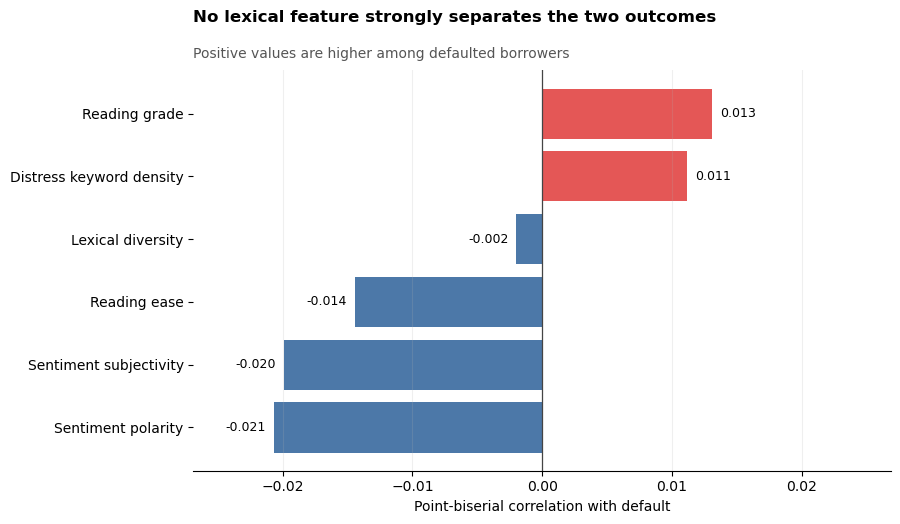

In [2]:
display(
    correlations[[
        'feature', 'point_biserial_r', 'p_value',
        'non_default_mean', 'default_mean', 'default_minus_non_default'
    ]].style.format({
        'point_biserial_r': '{:.4f}',
        'p_value': '{:.3g}',
        'non_default_mean': '{:.4f}',
        'default_mean': '{:.4f}',
        'default_minus_non_default': '{:.4f}',
    })
)

build_correlation_figure(correlations)
plt.show()

The sign tells us which outcome has the higher average. The bar length is more important than the p-value here, and every bar is short.

## 2. Outcome summaries tell the same story

The raw means make the size of the gaps easier to read. Defaulted borrowers score about 0.12 of a grade level higher and roughly one point lower on Flesch reading ease. Their mean distress density is 0.267% of words, compared with 0.220% for non-defaulted borrowers. None of those differences is large.

outcome,default,non_default,default_minus_non_default
feature,,,
financial_distress_keyword_density,0.00267,0.00220,0.00047
flesch_kincaid_grade,8.34674,8.22766,0.11909
flesch_reading_ease,50.77058,51.82505,-1.05447
lexical_diversity_ttr,0.78609,0.78674,-0.00065
sentiment_polarity,0.09277,0.10264,-0.00986
sentiment_subjectivity,0.34144,0.35441,-0.01297


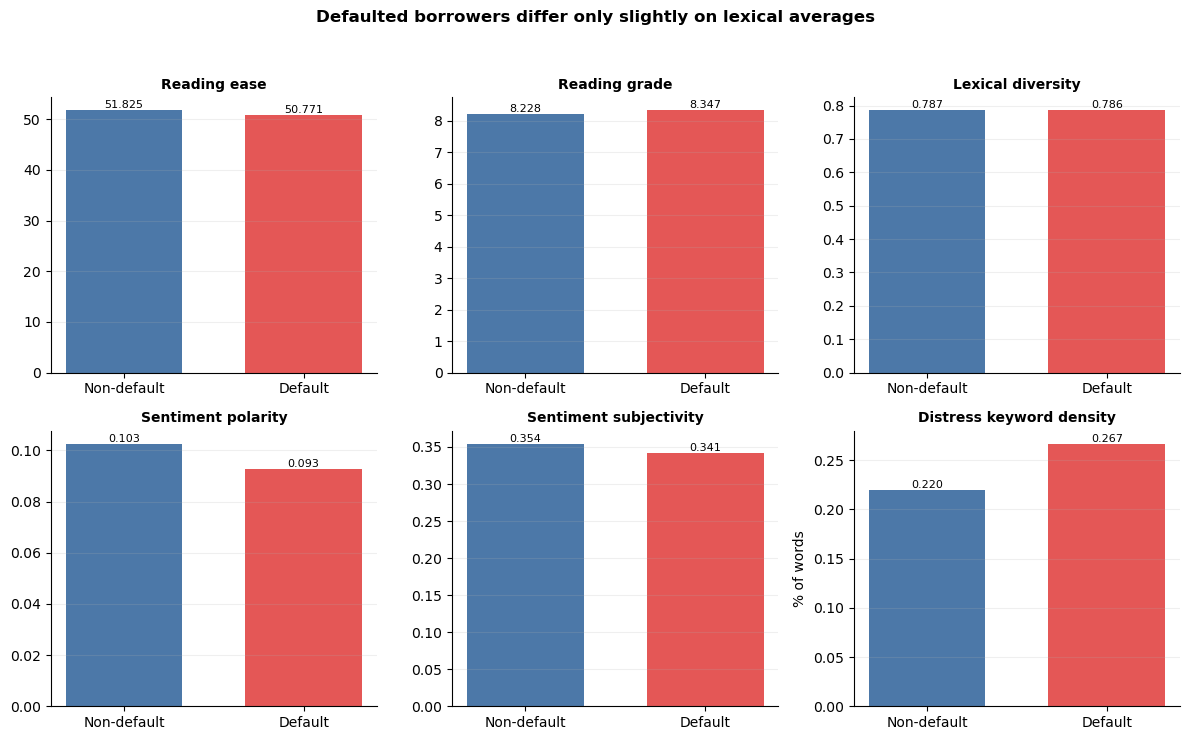

In [3]:
outcome_means = outcome_summary.pivot(index='feature', columns='outcome', values='mean')
outcome_means['default_minus_non_default'] = (
    outcome_means['default'] - outcome_means['non_default']
)
display(outcome_means.style.format('{:.5f}'))

build_outcome_means_figure(outcome_summary)
plt.show()

The panels use each feature's natural scale. Compare the two bars within a panel, not bar heights across different panels. Full quartiles, ranges, and standard deviations are available in `reports/nlp/lexical_feature_outcome_summary.csv`.

## 3. Loan purpose shows larger outcome differences

`small_business` has the highest empirical default rate at **26.8%**. `debt_consolidation`, the largest group, is at **16.2%**. Their mean reading grades are close, 8.66 and 8.90 respectively, so writing complexity does not explain the gap in this table. Loan size, borrower profile, and lending vintage may differ across purposes, and this grouped view does not adjust for any of them.

,purpose,n_loans,mean_reading_ease,mean_reading_grade,mean_distress_keyword_density,empirical_default_rate
11,small_business,2405,51.82,8.66,0.00079,26.8%
10,renewable_energy,117,44.28,9.36,0.00145,20.5%
9,other,5313,56.22,7.49,0.00403,17.9%
3,educational,290,51.61,8.89,0.00089,17.6%
7,medical,849,46.04,8.94,0.09357,16.4%
2,debt_consolidation,48439,47.00,8.90,0.00145,16.2%
12,vacation,471,49.44,8.33,0.00164,15.5%
5,house,720,65.30,6.37,0.00066,15.3%
8,moving,677,58.21,7.58,0.00060,14.2%
13,wedding,1193,62.52,6.87,0.00045,12.7%


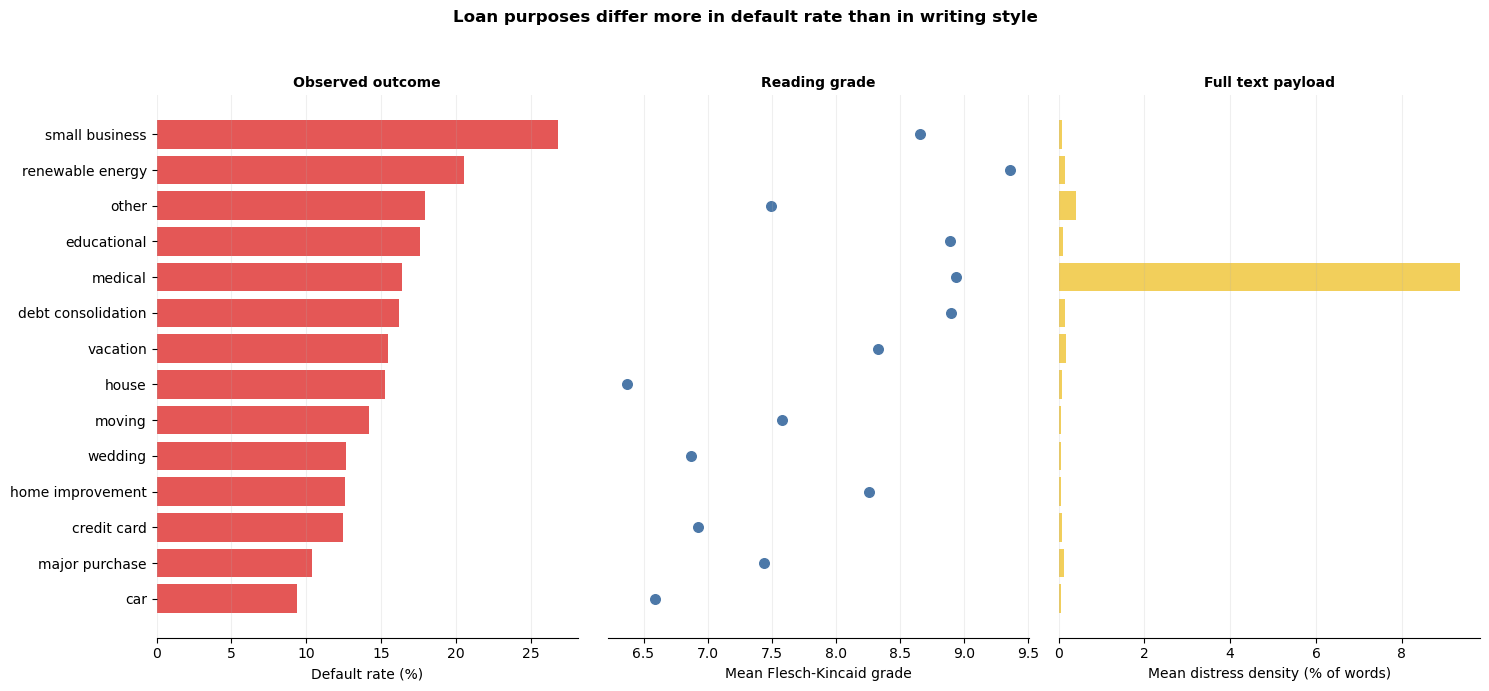

In [4]:
purpose_view = purpose_summary[[
    'purpose', 'n_loans', 'mean_reading_ease', 'mean_reading_grade',
    'mean_distress_keyword_density', 'empirical_default_rate'
]].sort_values('empirical_default_rate', ascending=False)
display(
    purpose_view.style.format({
        'mean_reading_ease': '{:.2f}',
        'mean_reading_grade': '{:.2f}',
        'mean_distress_keyword_density': '{:.5f}',
        'empirical_default_rate': '{:.1%}',
    })
)

build_purpose_profile_figure(purpose_summary)
plt.show()

The medical group is the clear outlier for full-payload distress density. That spike needs a source check before anyone interprets it as unusually distressed prose.

## 4. The medical label changes the keyword feature

The distress list contains the word `medical`, and every row in the medical category includes `Purpose: medical` in its text payload. As a result, all 849 medical loans receive at least one distress hit before the description is considered.

For **43.8%** of medical rows, the purpose field contains the configured keyword while the borrower's description contains none. The purpose label supplies **43.1%** of all distress hits inside the medical category and **11.6%** of distress hits across the full training split. The feature still captures real prose in some cases, but its medical-category spike is partly built into the payload design.

,purpose,payload_distress_hits,purpose_label_distress_hits,title_distress_hits,description_distress_hits,desc_distress_mention_rate,purpose_label_only_hit_rate
7,medical,1970,849,488,633,56.2%,43.8%


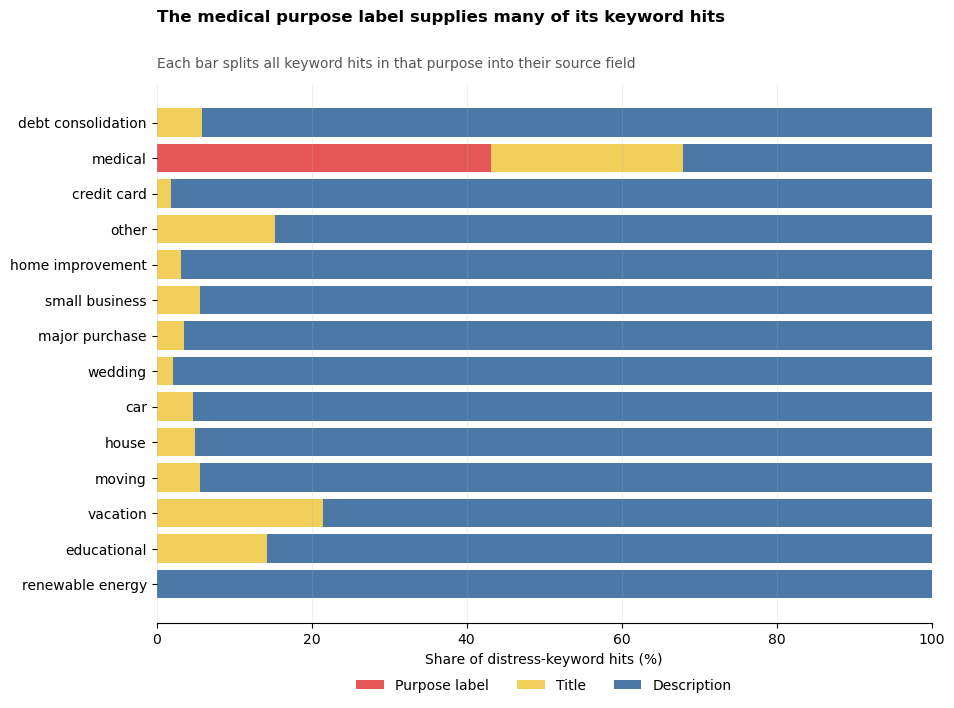

In [5]:
artifact_columns = [
    'purpose', 'payload_distress_hits', 'purpose_label_distress_hits',
    'title_distress_hits', 'description_distress_hits',
    'desc_distress_mention_rate', 'purpose_label_only_hit_rate'
]
display(
    purpose_summary.loc[purpose_summary['purpose'].eq('medical'), artifact_columns]
    .style.format({
        'desc_distress_mention_rate': '{:.1%}',
        'purpose_label_only_hit_rate': '{:.1%}',
    })
)

build_keyword_sources_figure(purpose_summary)
plt.show()

For analysis of borrower language, use `mean_desc_distress_keyword_density` or `desc_distress_mention_rate`. The full-payload feature remains valid as a model input, but it should be described as a blend of purpose, title, and description text.

## Boundaries of this analysis

These results describe one frozen training sample from LendingClub, which is a proxy population for this project. Point-biserial correlation measures one feature at a time and does not account for confounding or interactions. The purpose default rates are unadjusted. No result here establishes causality, and none uses the locked test split.

## Reproduce the results

From the repository root, with the approved raw CSV in `data/raw/loan.csv`, run:

```text
python -m src.nlp.lexical_eda
```

The command refreshes the CSV tables, JSON summary, report, and four PNG figures used by this notebook.